In [1]:
import sys
sys.path.insert(0, '..')
import importlib

import importlib                                                                                                                                              
import numpy as np                                                                                                                                            
import matplotlib.pyplot as plt                                                                                                                               
from scipy.signal import find_peaks     
                                                                                                                                                                
from src import params as p                                                                                                                                   
from src import ode, simulate
from src.food import TRE                                                                                                                                      
from src.params import num  

In [ ]:
# FOOD ON - TRE

DURATION_H = 72.0
food_fn = lambda t: TRE(t, num(2.1))

def run_lesion(sd, da, direct=False):
    p.LESION_SD = sd
    p.LESION_DA = da
    setattr(p, "DIRECT_SCN_TO_AGRP", direct)
    importlib.reload(ode); importlib.reload(simulate)
    return simulate.run(food_fn=food_fn, duration_h=DURATION_H,
                          max_step=np.inf, dt=1.0, rtol=1e-4, atol=1e-7)

res_control = run_lesion(1.0, 1.0, direct=False)
res_spz     = run_lesion(0.0, 1.0, direct=False)
res_dmh     = run_lesion(1.0, 0.0, direct=False)

#restoring
p.LESION_SD = 1.0
p.LESION_DA = 1.0
setattr(p, "DIRECT_SCN_TO_AGRP", False)                                                                                                                                          
                                                                                                                                                                        

In [ ]:
# Compare different contributions to AgRP activity in control condition

from src.currents import I_GLU_Trh, I_Na, I_K, I_GLU, I_OREXIN, I_GHSR, I_LEPR, I_INSR
from src.currents import aNa_inf

print(I_GLU_Trh(res_control.A, res_control.aGLUD).mean())
print(I_Na(aNa_inf(res_control.A), res_control.A).mean())
print(I_K(res_control.aKA, res_control.A).mean())
print(I_GLU(res_control.A, res_control.aGLUV).mean())
print(I_OREXIN(res_control.A, res_control.aOrexina).mean())
print(I_GHSR(res_control.A, res_control.AGHSR, -10.0).mean())
print(I_LEPR(res_control.A, res_control.ALEPR, -90.0).mean())

# NOTE: I_Glu_Trh is smallest contributor to AgRP activity.


-0.09110395266734451
-5.905100339265815
6.045975980589058
-0.3911445933904878
-0.6514890451304541
-2.0278765352752157
1.0250736563418252


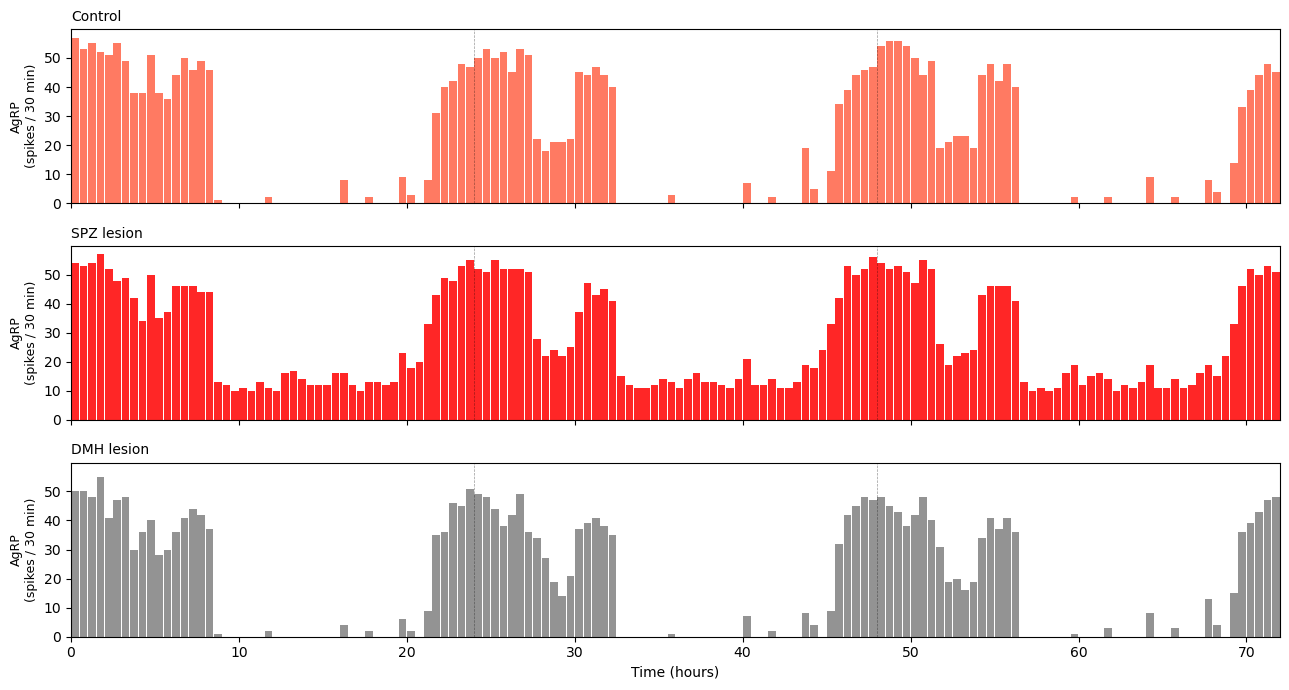

In [7]:
def spike_rate(res, window_h=0.5):      
      edges = np.arange(0.0, DURATION_H + window_h, window_h)                                                                                                   
      centers = (edges[:-1] + edges[1:]) / 2                                                                                                                    
      counts = []                             
      for i in range(len(edges) - 1):                                                                                                                           
          seg = res.A[(res.t_s >= edges[i]*3600) & (res.t_s < edges[i+1]*3600)]
          pks, _ = find_peaks(seg, height=0.0, distance=10)                                                                                                     
          counts.append(len(pks))         
      return centers, np.array(counts)                                                                                                                          
                                                                                                                                                                
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True, sharey=True)                                                                                     
                                                                           
for ax, res, label, color in [                                                                                                                                
    (axes[0], res_control, 'Control',    'tomato'),
    (axes[1], res_spz,     'SPZ lesion', 'red'),  
    (axes[2], res_dmh,     'DMH lesion', 'gray'),                                                                                                             
  ]:                                               
    centers, counts = spike_rate(res)                                                                                                                         
    ax.bar(centers, counts, width=0.45, color=color, alpha=0.85)                                                                                              
    ax.set_ylabel('AgRP\n(spikes / 30 min)', fontsize=9)        
    ax.set_title(label, fontsize=10, loc='left')                                                                                                              
    for d in (24, 48):                          
        ax.axvline(d, color='k', lw=0.5, ls='--', alpha=0.4)                                                                                                  
                                                              
axes[-1].set_xlabel('Time (hours)')                                                                                                                           
axes[-1].set_xlim(0, DURATION_H)   
plt.tight_layout()                                                                                                                                            
plt.show() 

In [8]:
# Compare with data from Douglass et al. Fig 6L, AgRP activity following DMH lesion
import pandas as pd
control_data = pd.read_csv('../data/Figure_6L_GFP-Douglass.csv')
lesion_data = pd.read_csv('../data/Figure_6L_TeNT-Douglass.csv')

In [9]:
print(control_data.columns.tolist())

['time', 'm1', 'm2', 'm3', 'm4', 'm5']


/var/folders/q6/cc2w_17s7mn0xrh5jhdy3n1r0000gn/T/ipykernel_13799/1402585857.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


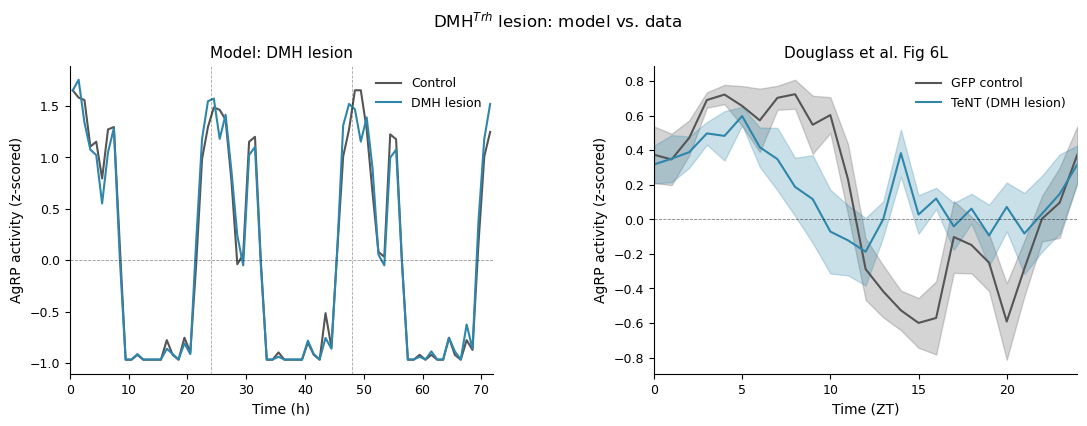

In [ ]:
COLORS = dict(control='#555555', lesion='#2E86AB')

def spike_rate_h(res, window_h=1.0):
    edges   = np.arange(0.0, DURATION_H + window_h, window_h)
    centers = (edges[:-1] + edges[1:]) / 2
    counts  = []
    for i in range(len(edges) - 1):
        seg = res.A[(res.t_s >= edges[i]*3600) & (res.t_s < edges[i+1]*3600)]
        pks, _ = find_peaks(seg, height=0.0, distance=10)
        counts.append(len(pks))
    return centers, np.array(counts, dtype=float)

def zscore(x):
    return (x - x.mean()) / x.std()

ctrl_t, ctrl_c = spike_rate_h(res_control)
dmh_t,  dmh_c  = spike_rate_h(res_dmh)
ctrl_c = zscore(ctrl_c)
dmh_c  = zscore(dmh_c)

# excl time column
mice_cols = [c for c in control_data.columns if c != 'time']
t_zt      = control_data['time'].values
ctrl_mean = control_data[mice_cols].mean(axis=1).values
ctrl_sem  = control_data[mice_cols].sem(axis=1).values
les_mean  = lesion_data[mice_cols].mean(axis=1).values
les_sem   = lesion_data[mice_cols].sem(axis=1).values

# fig
fig, (ax_model, ax_data) = plt.subplots(1, 2, figsize=(13, 4),
                                         gridspec_kw=dict(wspace=0.38))

# left — model (z-scored)
for t, c, label in [(ctrl_t, ctrl_c, 'Control'), (dmh_t, dmh_c, 'DMH lesion')]:
    ax_model.plot(t, c, color=COLORS['control' if 'Control' in label else 'lesion'],
                  lw=1.5, label=label)
for d in (24, 48):
    ax_model.axvline(d, color='k', lw=0.6, ls='--', alpha=0.35)
ax_model.axhline(0, color='k', lw=0.6, ls='--', alpha=0.4)
ax_model.set_xlim(0, DURATION_H)
ax_model.set_xlabel('Time (h)')
ax_model.set_ylabel('AgRP activity (z-scored)')
ax_model.set_title('Model: DMH lesion', fontsize=11)
ax_model.legend(frameon=False, fontsize=9)

# right — Douglass Fig 6L
for mean, sem, label, key in [
    (ctrl_mean, ctrl_sem, 'GFP control',      'control'),
    (les_mean,  les_sem,  'TeNT (DMH lesion)', 'lesion'),
]:
    ax_data.plot(t_zt, mean, color=COLORS[key], lw=1.5, label=label)
    ax_data.fill_between(t_zt, mean - sem, mean + sem,
                         alpha=0.25, color=COLORS[key])
ax_data.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5)
ax_data.set_xlim(t_zt[0], t_zt[-1])
ax_data.set_xlabel('Time (ZT)')
ax_data.set_ylabel('AgRP activity (z-scored)')
ax_data.set_title('Douglass', fontsize=11)
ax_data.legend(frameon=False, fontsize=9)

for ax in (ax_model, ax_data):
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=9)

plt.suptitle(r'DMH$^{Trh}$ lesion: model vs. data', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# FOOD OFF

DURATION_H = 72.0                       
food_fn_zero = lambda t: 0
                                                                                                                                                                

def run_lesion(sd, da):                                                                                                                                       
    p.LESION_SD = sd                    
    p.LESION_DA = da
    importlib.reload(ode); importlib.reload(simulate)                                                                                                         
    return simulate.run(food_fn=food_fn_zero, duration_h=DURATION_H,
               max_step=np.inf, dt=1.0, rtol=1e-4, atol=1e-7)     
                                                                                                                                                                
res_control_zero = run_lesion(1.0, 1.0)                                                                                                                          
res_spz_zero     = run_lesion(0.0, 1.0)      
res_dmh_zero     = run_lesion(1.0, 0.0)                                                                                                                            
                                                                                                                                                                
p.LESION_SD = 1.0                           
p.LESION_DA = 1.0   

In [52]:
for name, res in [("food_on", res_control), ("food_off", res_control_zero)]:
    print(f"\n{name}")
    print(f"Ghrelin H1:        {res.H1.mean():.1f} pg/mL")
    print(f"Insulin IN:        {res.IN.mean():.1f} pM")
    print(f"Leptin LP:         {res.LP.mean():.1f} ng/mL")
    print(f"AGHSR (receptor):  {res.AGHSR.mean():.3f}")
    print(f"AINSR (receptor):  {res.AINSR.mean():.3f}")
    print(f"ALEPR (receptor):  {res.ALEPR.mean():.3f}")


food_on
Ghrelin H1:        550.5 pg/mL
Insulin IN:        191.6 pM
Leptin LP:         20.1 ng/mL
AGHSR (receptor):  0.520
AINSR (receptor):  0.211
ALEPR (receptor):  0.555

food_off
Ghrelin H1:        656.9 pg/mL
Insulin IN:        87.3 pM
Leptin LP:         22.5 ng/mL
AGHSR (receptor):  0.567
AINSR (receptor):  0.117
ALEPR (receptor):  0.584


In [28]:
from src.currents import I_OREXIN, I_GLU_Trh

print(f"I_OREXIN mean:   {I_OREXIN(res_control.A, res_control.aOrexina).mean():.4f}")
print(f"I_GLU_Trh mean:  {I_GLU_Trh(res_control.A, res_control.aGLUD).mean():.4f}")

I_OREXIN mean:   -0.6515
I_GLU_Trh mean:  -0.0911


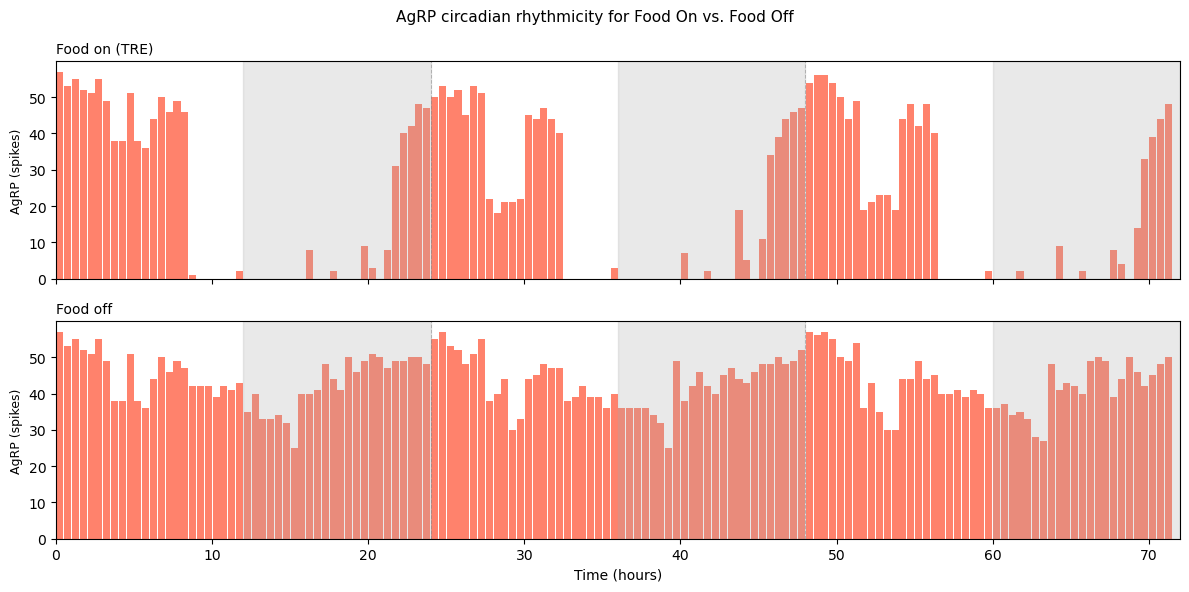

In [51]:
import importlib
import src.plot as plot
importlib.reload(plot)
from src.plot import plot_spike_counts, _MEAL_SPANS_72H

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
  
plot_spike_counts(res=res_control,      axes=ax1, neurons=["A"],
                    meal_spans=[], t_range=(0, 72.0), zscore=False)
plot_spike_counts(res=res_control_zero, axes=ax2, neurons=["A"],
                    meal_spans=[], t_range=(0, 72.0), zscore=False)

ax1.set_title('Food on (TRE)', loc='left', fontsize=10)
ax2.set_title('Food off',      loc='left', fontsize=10)

for ax in (ax1, ax2):
      for dark_start in [12, 36, 60]:
          ax.axvspan(dark_start, dark_start + 12, alpha=0.25, color='darkgray')

ax1.set_xlabel('')
plt.suptitle('AgRP circadian rhythmicity for Food On vs. Food Off', fontsize=11)
plt.tight_layout()
plt.show()